# Data Quality Analysis

In [1]:
import pandas as pd 
import numpy as np
from helper.loader.Read_Dataset import read_participant_data, get_dataset_paths
from helper.loader.evaulation_area import EvaluationArea
from helper.loader.create_dataframe import CreateDataset
from helper.loader.position_alignment import transform_coordinates_test_area, transform_coordinates

In [2]:
p1_id = ['participant_1', 'participant_3', 'participant_4', 'participant_5', 'participant_6', 'participant_7', 'participant_8','participant_9','participant_10','participant_2'] 
data_paths_p1 = get_dataset_paths(participants_list=p1_id, long_data=True, forward_data=True, back_data=True)

Processing participants: ['participant_1', 'participant_3', 'participant_4', 'participant_5', 'participant_6', 'participant_7', 'participant_8', 'participant_9', 'participant_10', 'participant_2']


## 1. Loop Closure Error

The loop closure error measures positional drift: the straight-line distance between the start and end point of a trajectory that should close back on itself. A low drift relative to total path length indicates good tracking accuracy.

In [17]:
# Load and transform all participant trajectories
ls = []
path_ls = []
construct_ls = []

for participant in data_paths_p1.keys():
    dict_act = data_paths_p1[participant]
    for construct in dict_act.keys():
        try:
            path = dict_act[construct]['video_holo']
            df = pd.read_csv(path)

            coords, indices = (
                transform_coordinates_test_area(df) if construct != "long"
                else transform_coordinates(df)
            )
            if coords is not None:
                df_clean = df.loc[indices].copy()
                df_clean['x_new'] = coords[:, 0] * 100  # convert to cm
                df_clean['y_new'] = coords[:, 1] * 100
                df_clean.dropna(inplace=True)
                ls.append(df_clean)
                path_ls.append(path)
                construct_ls.append(construct)
        except Exception:
            continue

# Compute loop closure metrics for each trajectory
euclidean_distances = []  # drift: straight-line distance between start and end
absolute_distances = []   # total path length (sum of step distances)
error_ratios = []         # drift as a percentage of total path length
constructs = []

for trial_idx, df in enumerate(ls):
    x_start, y_start = df.iloc[0]['x_new'], df.iloc[0]['y_new']
    x_end, y_end = df.iloc[-1]['x_new'], df.iloc[-1]['y_new']

    euclidean_dist = np.sqrt((x_end - x_start)**2 + (y_end - y_start)**2)

    absolute_dist = sum(
        np.sqrt((df.iloc[i + 1]['x_new'] - df.iloc[i]['x_new'])**2 +
                (df.iloc[i + 1]['y_new'] - df.iloc[i]['y_new'])**2)
        for i in range(len(df) - 1)
    )

    error_ratio = (euclidean_dist / absolute_dist * 100) if absolute_dist > 0 else 0

    euclidean_distances.append(euclidean_dist)
    absolute_distances.append(absolute_dist)
    error_ratios.append(error_ratio)
    constructs.append(construct_ls[trial_idx])

# Aggregate results by construct
results_df = pd.DataFrame({
    'construct': constructs,
    'euclidean_dist': euclidean_distances,
    'absolute_dist': absolute_distances,
    'error_ratio': error_ratios
})

print("=== Statistics per Construct ===")
for construct in ['long', 'back', 'forward']:
    subset = results_df[results_df['construct'] == construct]
    if len(subset) > 0:
        print(f"\n{construct.upper()}:")
        print(f"  N = {len(subset)}")
        print(f"  Mean Drift:     {subset['euclidean_dist'].mean():.2f} cm (±{subset['euclidean_dist'].std():.2f})")
        print(f"  Mean Distance:  {subset['absolute_dist'].mean():.2f} cm (±{subset['absolute_dist'].std():.2f})")
        print(f"  Mean Error Ratio: {subset['error_ratio'].mean():.3f}%")

print("\n=== Overall ===")
print(f"Mean Drift:       {np.mean(euclidean_distances):.2f} cm")
print(f"Mean Distance:    {np.mean(absolute_distances):.2f} cm")
print(f"Mean Error Ratio: {np.mean(error_ratios):.3f}%")

=== Statistics per Construct ===

LONG:
  N = 4
  Mean Drift:     19.70 cm (±14.55)
  Mean Distance:  40957.51 cm (±3994.24)
  Mean Error Ratio: 0.046%

BACK:
  N = 6
  Mean Drift:     18.22 cm (±13.02)
  Mean Distance:  17654.80 cm (±50.94)
  Mean Error Ratio: 0.103%

FORWARD:
  N = 7
  Mean Drift:     21.92 cm (±18.17)
  Mean Distance:  18872.95 cm (±1784.63)
  Mean Error Ratio: 0.111%

=== Overall ===
Mean Drift:       20.09 cm
Mean Distance:    23639.38 cm
Mean Error Ratio: 0.093%


In [18]:
# Detailed step-level analysis: Forward vs Back
print("=== Detailed Analysis: Forward vs Back ===\n")

for construct in ['forward', 'back']:
    subset_indices = [i for i, c in enumerate(constructs) if c == construct]

    print(f"\n{construct.upper()}:")
    for idx in subset_indices:
        df = ls[idx]
        absolute_dist = absolute_distances[idx]

        step_distances = [
            np.sqrt((df.iloc[i + 1]['x_new'] - df.iloc[i]['x_new'])**2 +
                    (df.iloc[i + 1]['y_new'] - df.iloc[i]['y_new'])**2)
            for i in range(len(df) - 1)
        ]

        label = '/'.join(path_ls[idx].split('/')[-3:-1])
        print(f"  {label}: {absolute_dist:.2f} cm, {len(df)} points")
        print(f"    Avg step: {np.mean(step_distances):.2f} cm  "
              f"Median: {np.median(step_distances):.2f} cm  "
              f"Max: {np.max(step_distances):.2f} cm  "
              f"Std: {np.std(step_distances):.2f} cm")

# Summary statistics
forward_dists = [absolute_distances[i] for i, c in enumerate(constructs) if c == 'forward']
back_dists = [absolute_distances[i] for i, c in enumerate(constructs) if c == 'back']

print(f"\n=== Forward vs Back Comparison ===")
print(f"Forward: Mean={np.mean(forward_dists):.2f}  Std={np.std(forward_dists):.2f}  "
      f"Min={np.min(forward_dists):.2f}  Max={np.max(forward_dists):.2f}")
print(f"Back:    Mean={np.mean(back_dists):.2f}  Std={np.std(back_dists):.2f}  "
      f"Min={np.min(back_dists):.2f}  Max={np.max(back_dists):.2f}")
diff = np.mean(forward_dists) - np.mean(back_dists)
pct = (np.mean(forward_dists) / np.mean(back_dists) - 1) * 100
print(f"Difference: {diff:.2f} cm ({pct:.1f}%)")

# Statistical significance
from scipy import stats
t_stat, p_value = stats.ttest_ind(forward_dists, back_dists)
print(f"\nIndependent t-test: t={t_stat:.3f}, p={p_value:.3f}")
print(f"Significantly different (α=0.05): {'Yes' if p_value < 0.05 else 'No'}")

# Flag outliers relative to expected corridor length
expected_dist = 18200  # cm (~182 m)
print(f"\n=== Outliers (deviation > 1000 cm from expected {expected_dist} cm) ===")
all_trials = [
    (absolute_distances[i], constructs[i], path_ls[i])
    for i in range(len(constructs)) if constructs[i] in ['forward', 'back']
]
all_trials.sort(key=lambda x: x[0])

found = False
for dist, construct, path in all_trials:
    deviation = abs(dist - expected_dist)
    if deviation > 1000:
        label = '/'.join(path.split('/')[-3:-1])
        print(f"  {construct}: {dist:.2f} cm (deviation: {deviation:.2f} cm) — {label}")
        found = True
if not found:
    print("  None found.")

=== Detailed Analysis: Forward vs Back ===


FORWARD:
  forward/csv: 22552.55 cm, 5762 points
    Avg step: 3.91 cm  Median: 3.46 cm  Max: 1184.60 cm  Std: 30.83 cm
  forward/csv: 17874.74 cm, 4764 points
    Avg step: 3.75 cm  Median: 4.21 cm  Max: 33.70 cm  Std: 1.58 cm
  forward/csv: 18038.32 cm, 5668 points
    Avg step: 3.18 cm  Median: 3.89 cm  Max: 81.18 cm  Std: 1.91 cm
  forward/csv: 17924.08 cm, 4681 points
    Avg step: 3.83 cm  Median: 4.37 cm  Max: 52.31 cm  Std: 1.84 cm
  forward/csv: 17798.70 cm, 4532 points
    Avg step: 3.93 cm  Median: 4.40 cm  Max: 28.17 cm  Std: 1.45 cm
  forward/csv: 18010.63 cm, 5228 points
    Avg step: 3.45 cm  Median: 4.01 cm  Max: 109.12 cm  Std: 2.14 cm
  forward/csv: 19911.67 cm, 5141 points
    Avg step: 3.87 cm  Median: 3.94 cm  Max: 1080.67 cm  Std: 20.73 cm

BACK:
  back/csv: 17730.80 cm, 4297 points
    Avg step: 4.13 cm  Median: 4.60 cm  Max: 92.66 cm  Std: 2.43 cm
  back/csv: 17673.01 cm, 4929 points
    Avg step: 3.59 cm  Median: 4.0

In [19]:
def calculate_distance_filtered(df, threshold_cm=50):
    """Return (filtered_dist, removed_dist) after excluding step jumps above threshold."""
    filtered_dist = 0.0
    removed_dist = 0.0
    for i in range(len(df) - 1):
        x1, y1 = df.iloc[i]['x_new'], df.iloc[i]['y_new']
        x2, y2 = df.iloc[i + 1]['x_new'], df.iloc[i + 1]['y_new']
        step = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        if step <= threshold_cm:
            filtered_dist += step
        else:
            removed_dist += step
    return filtered_dist, removed_dist


print("=== Ground Truth Summary ===\n")

print("Variant 1: All data (including tracking artifacts)")
print("-" * 65)
for construct in ['long', 'forward', 'back']:
    subset = results_df[results_df['construct'] == construct]
    print(f"{construct.upper()}: N={len(subset)},  "
          f"Mean Distance={subset['absolute_dist'].mean():.2f} cm,  "
          f"Mean Drift={subset['euclidean_dist'].mean():.2f} cm,  "
          f"Error Rate={subset['error_ratio'].mean():.3f}%")

# Recompute with tracking-jump filter
filtered_results = []
for idx, df in enumerate(ls):
    filtered_dist, removed_dist = calculate_distance_filtered(df, threshold_cm=50)
    euclidean_dist = euclidean_distances[idx]
    error_ratio = (euclidean_dist / filtered_dist * 100) if filtered_dist > 0 else 0
    filtered_results.append({
        'construct': constructs[idx],
        'filtered_dist': filtered_dist,
        'removed_dist': removed_dist,
        'euclidean_dist': euclidean_dist,
        'error_ratio': error_ratio,
    })

filtered_df = pd.DataFrame(filtered_results)

print("\nVariant 2: Filtered (tracking jumps > 50 cm excluded)")
print("-" * 65)
for construct in ['long', 'forward', 'back']:
    subset = filtered_df[filtered_df['construct'] == construct]
    removed_total = subset['removed_dist'].sum()
    print(f"{construct.upper()}: N={len(subset)},  "
          f"Mean Distance={subset['filtered_dist'].mean():.2f} cm,  "
          f"Mean Drift={subset['euclidean_dist'].mean():.2f} cm,  "
          f"Error Rate={subset['error_ratio'].mean():.3f}%")
    print(f"  → Removed {removed_total:.2f} cm total from tracking jumps")

=== Ground Truth Summary ===

Variant 1: All data (including tracking artifacts)
-----------------------------------------------------------------
LONG: N=4,  Mean Distance=40957.51 cm,  Mean Drift=19.70 cm,  Error Rate=0.046%
FORWARD: N=7,  Mean Distance=18872.95 cm,  Mean Drift=21.92 cm,  Error Rate=0.111%
BACK: N=6,  Mean Distance=17654.80 cm,  Mean Drift=18.22 cm,  Error Rate=0.103%

Variant 2: Filtered (tracking jumps > 50 cm excluded)
-----------------------------------------------------------------
LONG: N=4,  Mean Distance=35432.47 cm,  Mean Drift=19.70 cm,  Error Rate=0.055%
  → Removed 22100.17 cm total from tracking jumps
FORWARD: N=7,  Mean Distance=17846.43 cm,  Mean Drift=21.92 cm,  Error Rate=0.123%
  → Removed 7185.64 cm total from tracking jumps
BACK: N=6,  Mean Distance=17595.93 cm,  Mean Drift=18.22 cm,  Error Rate=0.103%
  → Removed 353.22 cm total from tracking jumps


## 2. Synchronization Quality

In [20]:
import contextlib
import io
from helper.sync.synchronise import synchronise

sync_records = []

for participant in data_paths_p1.keys():
    dict_act = data_paths_p1[participant]
    for construct in dict_act.keys():
        paths = dict_act[construct]
        try:
            data_obj = {
                'video_holo':     pd.read_csv(paths['video_holo']),
                'video_android':  pd.read_csv(paths['video_android']),
                'sensor_android': pd.read_csv(paths['sensor_android']),
            }
            # Suppress per-trial console output from synchronise()
            with contextlib.redirect_stdout(io.StringIO()):
                df_merged, analysis = synchronise(data_obj, analysis=True)

            total_rows = len(df_merged)
            video_match_pct  = df_merged['timestamp_unix_pixel'].notna().sum() / total_rows * 100
            sensor_match_pct = df_merged['timestamp_unix_pixel_sensor'].notna().sum() / total_rows * 100

            sync_records.append({
                'participant':       participant,
                'construct':         construct,
                'total_rows':        total_rows,
                'video_match_pct':   video_match_pct,
                'sensor_match_pct':  sensor_match_pct,
                'avg_jitter_ms':     analysis['avg_jitter'],
                'max_jitter_ms':     analysis['max_jitter'],
            })
        except Exception:
            continue

sync_df = pd.DataFrame(sync_records)

print("=== Overall Synchronization Quality ===")
print(f"Trials analyzed:          {len(sync_df)}")
print(f"Mean video match rate:    {sync_df['video_match_pct'].mean():.2f}%")
print(f"Mean sensor match rate:   {sync_df['sensor_match_pct'].mean():.2f}%")
print(f"Mean time offset:         {sync_df['avg_jitter_ms'].mean():.2f} ms")
print(f"Max time offset (global): {sync_df['max_jitter_ms'].max():.2f} ms")

print("\nPer construct:")
for construct in ['long', 'forward', 'back']:
    subset = sync_df[sync_df['construct'] == construct]
    if len(subset) > 0:
        print(f"  {construct.upper():8s}: N={len(subset)},  "
              f"Video={subset['video_match_pct'].mean():.2f}%,  "
              f"Sensor={subset['sensor_match_pct'].mean():.2f}%,  "
              f"Avg Jitter={subset['avg_jitter_ms'].mean():.2f} ms")

=== Overall Synchronization Quality ===
Trials analyzed:          17
Mean video match rate:    99.30%
Mean sensor match rate:   92.31%
Mean time offset:         7.92 ms
Max time offset (global): 17.00 ms

Per construct:
  LONG    : N=4,  Video=99.22%,  Sensor=92.45%,  Avg Jitter=7.87 ms
  FORWARD : N=7,  Video=99.39%,  Sensor=92.50%,  Avg Jitter=7.86 ms
  BACK    : N=6,  Video=99.25%,  Sensor=91.99%,  Avg Jitter=8.03 ms


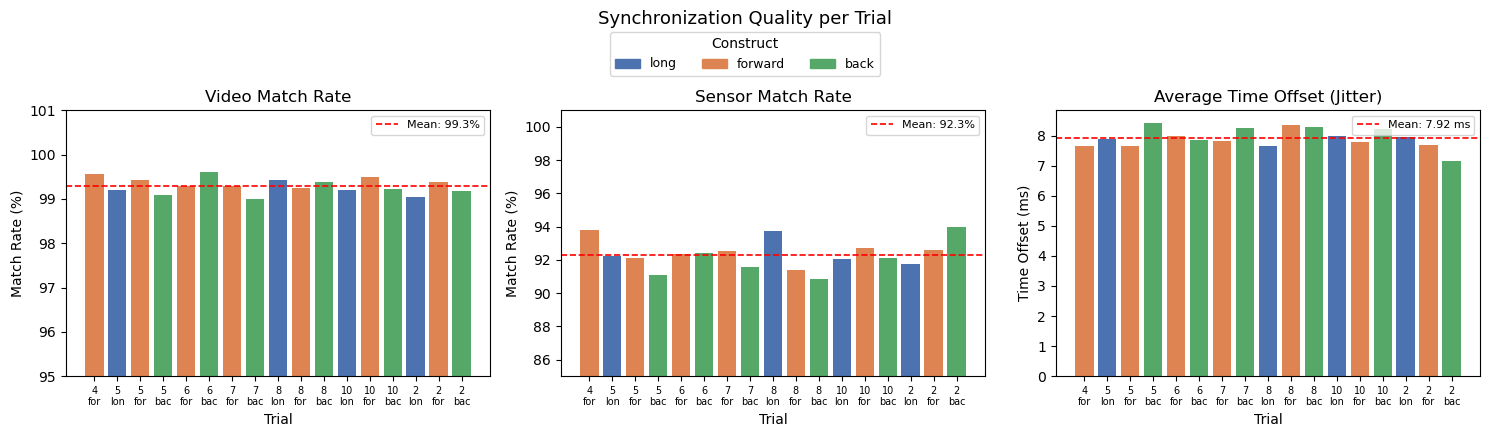

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

construct_colors = {'long': '#4C72B0', 'forward': '#DD8452', 'back': '#55A868'}
colors = [construct_colors[c] for c in sync_df['construct']]
x = range(len(sync_df))
trial_labels = [f"{r['participant'].split('_')[1]}\n{r['construct'][:3]}"
                for _, r in sync_df.iterrows()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Video match rate ---
axes[0].bar(x, sync_df['video_match_pct'], color=colors)
mean_v = sync_df['video_match_pct'].mean()
axes[0].axhline(mean_v, color='red', linestyle='--', linewidth=1.2,
                label=f"Mean: {mean_v:.1f}%")
axes[0].set_title('Video Match Rate')
axes[0].set_ylabel('Match Rate (%)')
axes[0].set_xlabel('Trial')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(trial_labels, fontsize=7)
axes[0].set_ylim(95, 101)
axes[0].legend(fontsize=8)

# --- Sensor match rate ---
axes[1].bar(x, sync_df['sensor_match_pct'], color=colors)
mean_s = sync_df['sensor_match_pct'].mean()
axes[1].axhline(mean_s, color='red', linestyle='--', linewidth=1.2,
                label=f"Mean: {mean_s:.1f}%")
axes[1].set_title('Sensor Match Rate')
axes[1].set_ylabel('Match Rate (%)')
axes[1].set_xlabel('Trial')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(trial_labels, fontsize=7)
axes[1].set_ylim(85, 101)
axes[1].legend(fontsize=8)

# --- Average time offset ---
axes[2].bar(x, sync_df['avg_jitter_ms'], color=colors)
mean_j = sync_df['avg_jitter_ms'].mean()
axes[2].axhline(mean_j, color='red', linestyle='--', linewidth=1.2,
                label=f"Mean: {mean_j:.2f} ms")
axes[2].set_title('Average Time Offset (Jitter)')
axes[2].set_ylabel('Time Offset (ms)')
axes[2].set_xlabel('Trial')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(trial_labels, fontsize=7)
axes[2].legend(fontsize=8)

# Shared legend for constructs
legend_patches = [mpatches.Patch(color=c, label=k) for k, c in construct_colors.items()]
fig.legend(handles=legend_patches, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.04), fontsize=9, title='Construct')

plt.suptitle('Synchronization Quality per Trial', fontsize=13, y=1.08)
plt.tight_layout()
plt.show()